## MNIST 학습 데이터 만들기

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, t_train),(x_test, t_test)=mnist.load_data()

print('\n train shape = ', x_train.shape, ', train label shape = ', t_train.shape)
print('test shape = ', x_test.shape, ', test label shape = ', t_test.shape)

print('\n train label = ',t_train)
print(' test label = ',t_test)
      


 train shape =  (60000, 28, 28) , train label shape =  (60000,)
test shape =  (10000, 28, 28) , test label shape =  (10000,)

 train label =  [5 0 4 ... 5 6 8]
 test label =  [7 2 1 ... 4 5 6]


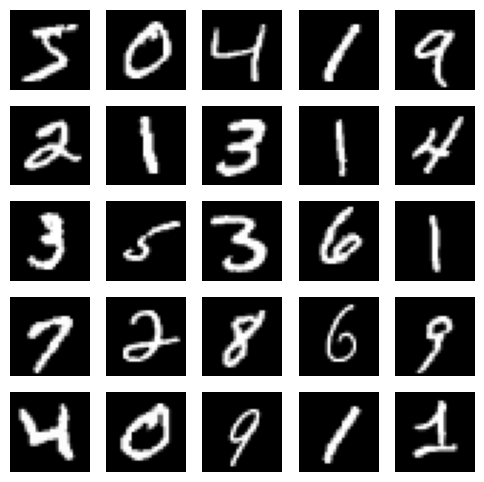

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for index in range(25):
    plt.subplot(5,5,index+1)
    plt.imshow(x_train[index],cmap='gray')
    plt.axis('off')
    
plt.show()

In [3]:
x_train=(x_train-0.0)/(255.0-0.0)
x_test=(x_test-0.0)/(255.0-0.0)

t_train=tf.keras.utils.to_categorical(t_train, num_classes=10)
t_test=tf.keras.utils.to_categorical(t_test, num_classes=10)

In [4]:
model=tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(100,activation='relu'))
model.add(tf.keras.layers.Dense(10,activation='softmax'))

C:\Users\dlwjd\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
hist=model.fit(x_train,t_train,epochs=30,validation_split=0.3)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9076 - loss: 0.3253 - val_accuracy: 0.9451 - val_loss: 0.1913
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9565 - loss: 0.1489 - val_accuracy: 0.9595 - val_loss: 0.1370
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9691 - loss: 0.1060 - val_accuracy: 0.9626 - val_loss: 0.1249
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9773 - loss: 0.0785 - val_accuracy: 0.9666 - val_loss: 0.1126
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9804 - loss: 0.0640 - val_accuracy: 0.9684 - val_loss: 0.1041
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9856 - loss: 0.0491 - val_accuracy: 0.9691 - val_loss: 0.1004
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9881 - loss: 0.0403 - val_accuracy: 0.9696 - val_loss: 0.1034
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9903 - 

In [7]:
model.evaluate(x_test,t_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9755 - loss: 0.1267


[0.12667696177959442, 0.9754999876022339]

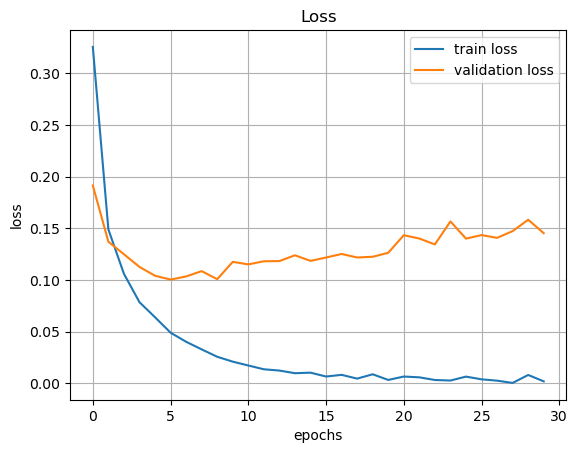

In [8]:
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()

plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='validation loss')

plt.legend(loc='best')

plt.show()

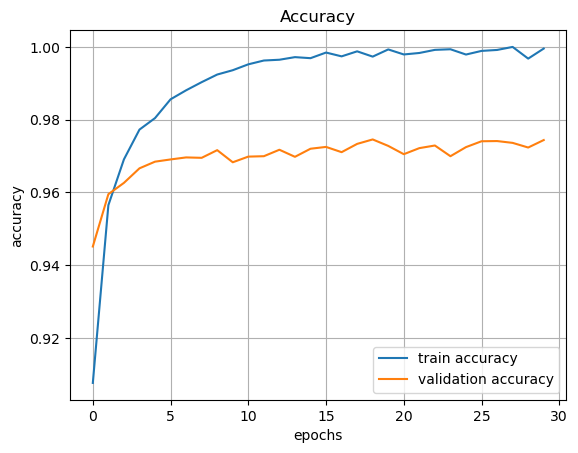

In [9]:
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()

plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='validation accuracy')

plt.legend(loc='best')

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


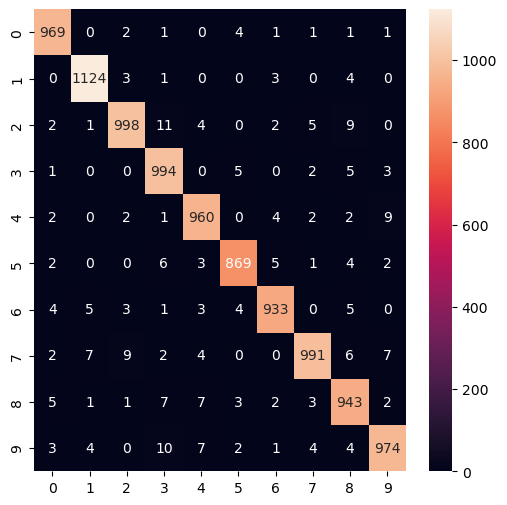

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(6,6))

predicted_value=model.predict(x_test)

cm=confusion_matrix(np.argmax(t_test,axis=-1),np.argmax(predicted_value,axis=1))

sns.heatmap(cm,annot=True,fmt='d')

plt.show()


In [11]:
print(cm)
print('\n')

for i in range(10):
    print(('label=%d\t(%d/%d)\taccuracy=%.3f')%
          (i,np.max(cm[i]),np.sum(cm[i]),
           np.max(cm[i])/np.sum(cm[i])))

[[ 969    0    2    1    0    4    1    1    1    1]
 [   0 1124    3    1    0    0    3    0    4    0]
 [   2    1  998   11    4    0    2    5    9    0]
 [   1    0    0  994    0    5    0    2    5    3]
 [   2    0    2    1  960    0    4    2    2    9]
 [   2    0    0    6    3  869    5    1    4    2]
 [   4    5    3    1    3    4  933    0    5    0]
 [   2    7    9    2    4    0    0  991    6    7]
 [   5    1    1    7    7    3    2    3  943    2]
 [   3    4    0   10    7    2    1    4    4  974]]


label=0	(969/980)	accuracy=0.989
label=1	(1124/1135)	accuracy=0.990
label=2	(998/1032)	accuracy=0.967
label=3	(994/1010)	accuracy=0.984
label=4	(960/982)	accuracy=0.978
label=5	(869/892)	accuracy=0.974
label=6	(933/958)	accuracy=0.974
label=7	(991/1028)	accuracy=0.964
label=8	(943/974)	accuracy=0.968
label=9	(974/1009)	accuracy=0.965
